In [113]:
import pandas as pd

df_orders = pd.read_csv('/content/olist_orders_dataset.csv')

df_orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,02-10-2017 10:56,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,24-07-2018 20:41,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018 00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,08-08-2018 08:38,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018 00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,18-11-2017 19:28,18-11-2017 19:45,22-11-2017 13:39,02-12-2017 00:28,15-12-2017 00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,13-02-2018 21:18,13-02-2018 22:20,14-02-2018 19:46,16-02-2018 18:17,26-02-2018 00:00


In [114]:
df_orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [115]:
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'], format='%d-%m-%Y %H:%M')

df_orders['month'] = df_orders['order_purchase_timestamp'].dt.to_period('M')

df_orders.groupby('month').size()
# MONTHLY ORDERS

,0
month,
2016-09,4
2016-10,324
2016-12,1
2017-01,800
2017-02,1780
2017-03,2682
2017-04,2404
2017-05,3700
2017-06,3245


<Axes: xlabel='month'>

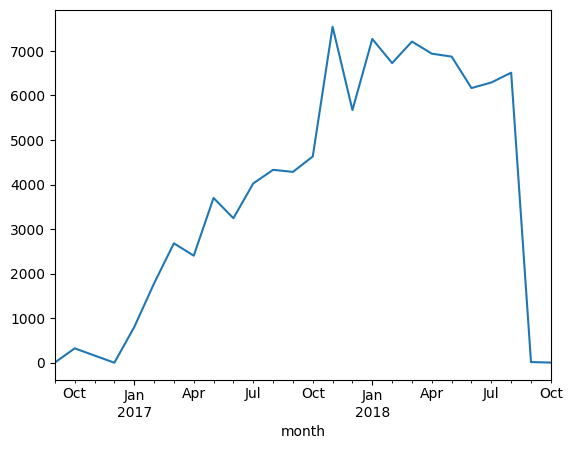

In [116]:
df_orders.groupby('month').size().plot()

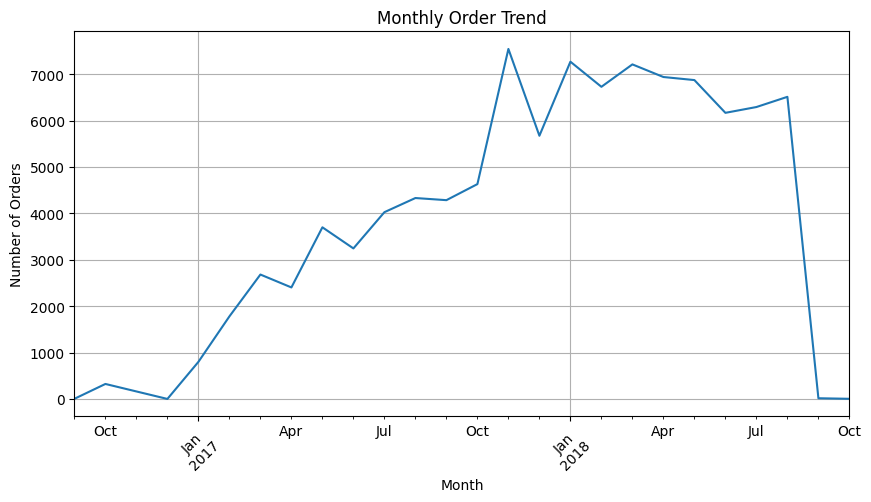

In [117]:
import matplotlib.pyplot as plt

monthly_orders = df_orders.groupby('month').size()

plt.figure(figsize=(10,5))
monthly_orders.plot()
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.grid()
plt.show()

In [118]:
# PERFORMANCE AS COMPARED TO PREVIOUS MONTH
monthly_orders = df_orders.groupby('month').size()

growth = monthly_orders.pct_change()*100

growth


,0
month,
2016-09,NaN
2016-10,8000.000000
2016-12,-99.691358
2017-01,79900.000000
2017-02,122.500000
2017-03,50.674157
2017-04,-10.365399
2017-05,53.910150
2017-06,-12.297297


In [119]:
growth_clean = growth[monthly_orders > 1000]

growth_clean

,0
month,
2017-02,122.500000
2017-03,50.674157
2017-04,-10.365399
2017-05,53.910150
2017-06,-12.297297
2017-07,24.067797
2017-08,7.575758
2017-09,-1.062110
2017-10,8.074679


In [120]:
df_order_payments = pd.read_csv('/content/olist_order_payments_dataset.csv')

df_order_payments.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [121]:
# TOTAL REVENUE
print(df_order_payments['payment_value'].sum())

16008872.12


In [122]:
df_merged = pd.merge(df_orders, df_order_payments, on='order_id')

df_merged.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month,payment_sequential,payment_type,payment_installments,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00,2017-10,1,credit_card,1,18.12
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00,2017-10,3,voucher,1,2.00
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00,2017-10,2,voucher,1,18.59
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018 00:00,2018-07,1,boleto,1,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018 00:00,2018-08,1,credit_card,3,179.12


In [123]:
# MONTHLY REVENUE
df_merged['month'] = pd.to_datetime(df_merged['order_purchase_timestamp']).dt.to_period('M')

monthly_revenue = df_merged.groupby('month')['payment_value'].sum()

monthly_revenue

,payment_value
month,
2016-09,252.24
2016-10,59090.48
2016-12,19.62
2017-01,138488.04
2017-02,291908.01
2017-03,449863.60
2017-04,417788.03
2017-05,592918.82
2017-06,511276.38


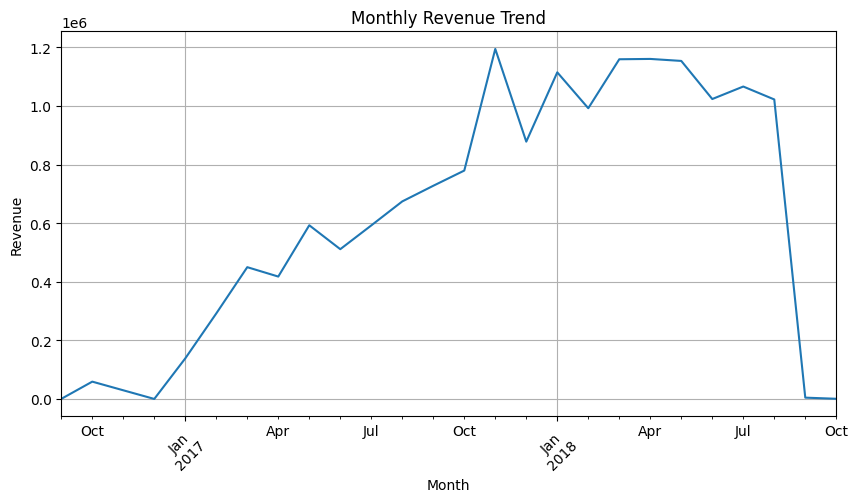

In [124]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
monthly_revenue.plot()
plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.grid()
plt.show()
#write insights Revenue shows a strong upward trend until November 2017, with minor fluctuations indicating steady business growth. From late 2017 to mid-2018, revenue stabilizes at a higher level, suggesting maturity in demand. A sharp decline is observed from July to October 2018, which may indicate incomplete data or a drop in business activity.

In [125]:
df_products = pd.read_csv('/content/olist_products_dataset.csv')

df_products.head()



,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [126]:
df_order_items = pd.read_csv('/content/olist_order_items_dataset.csv')

df_order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,total_price
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,19-09-2017 09:45,58.90,13.29,72.19
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,03-05-2017 11:05,239.90,19.93,259.83
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,18-01-2018 14:48,199.00,17.87,216.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,15-08-2018 10:10,12.99,12.79,25.78
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,13-02-2017 13:57,199.90,18.14,218.04


In [127]:
df_merge2 = pd.merge(df_products, df_order_items, on='product_id')

df_merge2.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_id,order_item_id,seller_id,shipping_limit_date,price,freight_value,total_price
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,e17e4f88e31525f7deef66779844ddce,1,5670f4db5b62c43d542e1b2d56b0cf7c,30-04-2018 17:33,10.91,7.39,18.30
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,5236307716393b7114b53ee991f36956,1,b561927807645834b59ef0d16ba55a24,06-02-2018 19:11,248.00,17.99,265.99
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,01f66e58769f84129811d43eefd187fb,1,7b07b3c7487f0ea825fc6df75abd658b,11-07-2018 21:30,79.80,7.82,87.62
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,143d00a4f2dde4e0364ee1821577adb3,1,c510bc1718f0f2961eaa42a23330681a,07-08-2018 09:10,112.30,9.54,121.84
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,86cafb8794cb99a9b1b77fc8e48fbbbb,1,0be8ff43f22e456b4e0371b2245e4d01,17-04-2018 01:30,37.90,8.29,46.19


In [128]:
df_full = pd.merge(df_merged, df_merge2, on='order_id')

df_full.head()
#

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month,payment_sequential,...,product_weight_g,product_length_cm,product_height_cm,product_width_cm,order_item_id,seller_id,shipping_limit_date,price,freight_value,total_price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00,2017-10,1,...,500.0,19.0,8.0,13.0,1,3504c0cb71d7fa48d967e0e4c94d59d9,06-10-2017 11:07,29.99,8.72,38.71
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00,2017-10,3,...,500.0,19.0,8.0,13.0,1,3504c0cb71d7fa48d967e0e4c94d59d9,06-10-2017 11:07,29.99,8.72,38.71
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00,2017-10,2,...,500.0,19.0,8.0,13.0,1,3504c0cb71d7fa48d967e0e4c94d59d9,06-10-2017 11:07,29.99,8.72,38.71
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018 00:00,2018-07,1,...,400.0,19.0,13.0,19.0,1,289cdb325fb7e7f891c38608bf9e0962,30-07-2018 03:24,118.70,22.76,141.46
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018 00:00,2018-08,1,...,420.0,24.0,19.0,21.0,1,4869f7a5dfa277a7dca6462dcf3b52b2,13-08-2018 08:55,159.90,19.22,179.12


In [129]:
# CATEGORY WISE TOTAL REVENUE
category_revenue = df_full.groupby('product_category_name')['payment_value'].sum().sort_values(ascending=False)

category_revenue.head(10)

,payment_value
product_category_name,
cama_mesa_banho,1712553.67
beleza_saude,1657373.12
informatica_acessorios,1585330.45
moveis_decoracao,1430176.39
relogios_presentes,1429216.68
esporte_lazer,1392127.56
utilidades_domesticas,1094758.13
automotivo,852294.33
ferramentas_jardim,838280.75


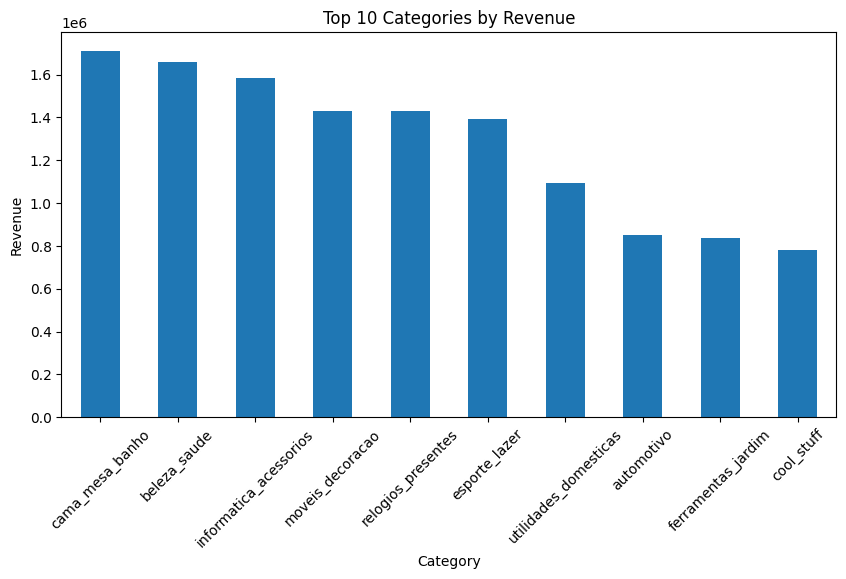

In [130]:
import matplotlib.pyplot as plt

category_revenue.head(10).plot(kind='bar', figsize=(10,5))
plt.title("Top 10 Categories by Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")
plt.xticks(rotation=45)
plt.show()
#insights
# The cama_mesa_banho (bed bath home products ) category emerges as the top revenue contributor, generating approximately ₹17 lakhs in sales.
#This indicates strong customer demand in home and lifestyle products, suggesting that this category is a key driver of overall business performance.
#The concentration of revenue in a few top categories highlights potential opportunities for targeted marketing and inventory optimization

In [131]:
df_customers = pd.read_csv('/content/olist_customers_dataset.csv')

df_customers.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [132]:
# RFM ANALYSIS (Customer Segmentation)

#  R = Recency (how recent purchase)
#  F = Frequency (how often)
#  M = Monetary (how much money)
df_all = pd.merge(df_merged, df_customers, on='customer_id')

df_all.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,month,payment_sequential,payment_type,payment_installments,payment_value,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00,2017-10,1,credit_card,1,18.12,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
1,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00,2017-10,3,voucher,1,2.00,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
2,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:00,02-10-2017 11:07,04-10-2017 19:55,10-10-2017 21:25,18-10-2017 00:00,2017-10,2,voucher,1,18.59,7c396fd4830fd04220f754e42b4e5bff,3149,sao paulo,SP
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:00,26-07-2018 03:24,26-07-2018 14:31,07-08-2018 15:27,13-08-2018 00:00,2018-07,1,boleto,1,141.46,af07308b275d755c9edb36a90c618231,47813,barreiras,BA
4,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:00,08-08-2018 08:55,08-08-2018 13:50,17-08-2018 18:06,04-09-2018 00:00,2018-08,1,credit_card,3,179.12,3a653a41f6f9fc3d2a113cf8398680e8,75265,vianopolis,GO


In [133]:
df_all['order_purchase_timestamp'] = pd.to_datetime(df_all['order_purchase_timestamp'])

In [134]:
import datetime as dt

reference_date = df_all['order_purchase_timestamp'].max() + dt.timedelta(days=1)

In [135]:
rfm = df_all.groupby('customer_unique_id').agg({
    'order_purchase_timestamp': lambda x: (reference_date - x.max()).days,
    'order_id': 'count',
    'payment_value': 'sum'
})

rfm.columns = ['Recency', 'Frequency', 'Monetary']

rfm.head()

,Recency,Frequency,Monetary
customer_unique_id,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19
0000f46a3911fa3c0805444483337064,586,1,86.22
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62
0004aac84e0df4da2b147fca70cf8255,337,1,196.89


In [136]:
rfm['R_score'] = pd.qcut(rfm['Recency'], 4, labels=[4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), 4, labels=[1,2,3,4])
rfm['M_score'] = pd.qcut(rfm['Monetary'], 4, labels=[1,2,3,4])

rfm['RFM_score'] = rfm['R_score'].astype(str) + rfm['F_score'].astype(str) + rfm['M_score'].astype(str)

rfm.head()

,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score
customer_unique_id,,,,,,,
0000366f3b9a7992bf8c76cfdf3221e2,161,1,141.90,4,1,3,413
0000b849f77a49e4a4ce2b2a4ca5be3f,164,1,27.19,4,1,1,411
0000f46a3911fa3c0805444483337064,586,1,86.22,1,1,2,112
0000f6ccb0745a6a4b88665a16c9f078,370,1,43.62,2,1,1,211
0004aac84e0df4da2b147fca70cf8255,337,1,196.89,2,1,4,214


In [137]:
def segment(row):
    if row == '444':
        return 'Champions'
    elif row[0] == '4':
        return 'Loyal'
    elif row[2] == '4':
        return 'Big Spenders'
    else:
        return 'Others'

rfm['Segment'] = rfm['RFM_score'].apply(segment)

rfm['Segment'].value_counts()

,count
Segment,
Others,54168
Loyal,22201
Big Spenders,17863
Champions,1863


<Axes: xlabel='Segment'>

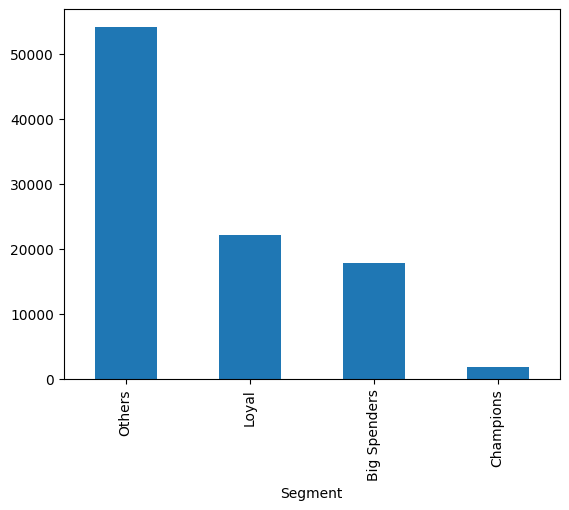

In [138]:
rfm['Segment'].value_counts().plot(kind='bar')

SQL


In [139]:
!pip install pandasql

In [140]:
import pandas as pd
import pandasql as ps

In [141]:
df_orders = pd.read_csv('olist_orders_dataset.csv')
df_payments = pd.read_csv('olist_order_payments_dataset.csv')
df_customers = pd.read_csv('olist_customers_dataset.csv')

In [142]:
df_orders['order_purchase_timestamp'] = pd.to_datetime(df_orders['order_purchase_timestamp'], format='%d-%m-%Y %H:%M')
#imp

In [143]:
#monthly orders
query1 = """
SELECT
    substr(order_purchase_timestamp,1,7) as month,
    COUNT(order_id) as total_orders
FROM df_orders
GROUP BY month
ORDER BY month
"""

ps.sqldf(query1)

,month,total_orders
0,2016-09,4
1,2016-10,324
2,2016-12,1
3,2017-01,800
4,2017-02,1780
5,2017-03,2682
6,2017-04,2404
7,2017-05,3700
8,2017-06,3245
9,2017-07,4026


In [144]:
# monthly revenue
query2 = """
SELECT
    substr(o.order_purchase_timestamp,1,7) as month,
    SUM(p.payment_value) as revenue
FROM df_orders o
JOIN df_payments p
ON o.order_id = p.order_id
GROUP BY month
ORDER BY month
"""

ps.sqldf(query2)


,month,revenue
0,2016-09,252.24
1,2016-10,59090.48
2,2016-12,19.62
3,2017-01,138488.04
4,2017-02,291908.01
5,2017-03,449863.60
6,2017-04,417788.03
7,2017-05,592918.82
8,2017-06,511276.38
9,2017-07,592382.92


In [145]:
# TOP 10 CUSTOMERS
query3 = """
SELECT
    o.customer_id,
    SUM(p.payment_value) as total_spent
FROM df_orders o
JOIN df_payments p
ON o.order_id = p.order_id
GROUP BY o.customer_id
ORDER BY total_spent DESC
LIMIT 10
"""

ps.sqldf(query3)

,customer_id,total_spent
0,1617b1357756262bfa56ab541c47bc16,13664.08
1,ec5b2ba62e574342386871631fafd3fc,7274.88
2,c6e2731c5b391845f6800c97401a43a9,6929.31
3,f48d464a0baaea338cb25f816991ab1f,6922.21
4,3fd6777bbce08a352fddd04e4a7cc8f6,6726.66
5,05455dfa7cd02f13d132aa7a6a9729c6,6081.54
6,df55c14d1476a9a3467f131269c2477f,4950.34
7,e0a2412720e9ea4f26c1ac985f6a7358,4809.44
8,24bbf5fd2f2e1b359ee7de94defc4a15,4764.34
9,3d979689f636322c62418b6346b1c6d2,4681.78


In [146]:
# AVERAGE ORDER VALUE
query4 = """
SELECT
    AVG(payment_value) as avg_order_value
FROM df_payments
"""

ps.sqldf(query4)

,avg_order_value
0,154.10038


In [147]:
# TOTAL REVENUE
query = """
SELECT
    SUM(payment_value) AS total_revenue
FROM df_payments
"""

ps.sqldf(query)


,total_revenue
0,1.600887e+07
